In [2]:
# # 05 - Sales forecasting
#
# Daily net product revenue, 2017-01-01 to 2018-08-31 (606 days).
# Weekly seasonality validated in EDA E13 (weekends ~32% below weekdays), so
# the seasonal period is 7.
#
# **No random splits anywhere.** Evaluation is rolling-origin backtesting:
# train to time t, forecast t+1..t+30, roll forward, repeat.
#
# **No LSTM.** 606 observations against thousands of parameters. Choosing not to
# is the defensible engineering decision; a badly-fit LSTM is not.

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root :", ROOT)

project root : c:\DS-AI-Spiced\PropheticIQ_AI_Powered_Ecom_Platform


In [3]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from src.data.prepare import build_order_frame
from src.models.forecast import (
    LAGS, ROLL_WINDOWS, SEASONAL_PERIOD,
    build_daily_revenue, make_supervised, rolling_origin_folds, score,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 200)

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIG = ROOT / "reports" / "figures" / "forecast"
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig

HORIZON = 30

In [5]:
# ## Build the daily series

order_frame = build_order_frame()
series = build_daily_revenue(order_frame)
y = series.to_numpy()

print(f"days              {len(series)}")
print(f"range             {series.index.min().date()} .. {series.index.max().date()}")
print(f"median daily      {series.median():,.0f} BRL")
print(f"zero-revenue days {(series == 0).sum()}")

days              600
range             2017-01-01 .. 2018-08-23
median daily      20,338 BRL
zero-revenue days 4


seasonal amplitude  8,339 BRL
residual std        5,668 BRL  <- roughly the accuracy ceiling


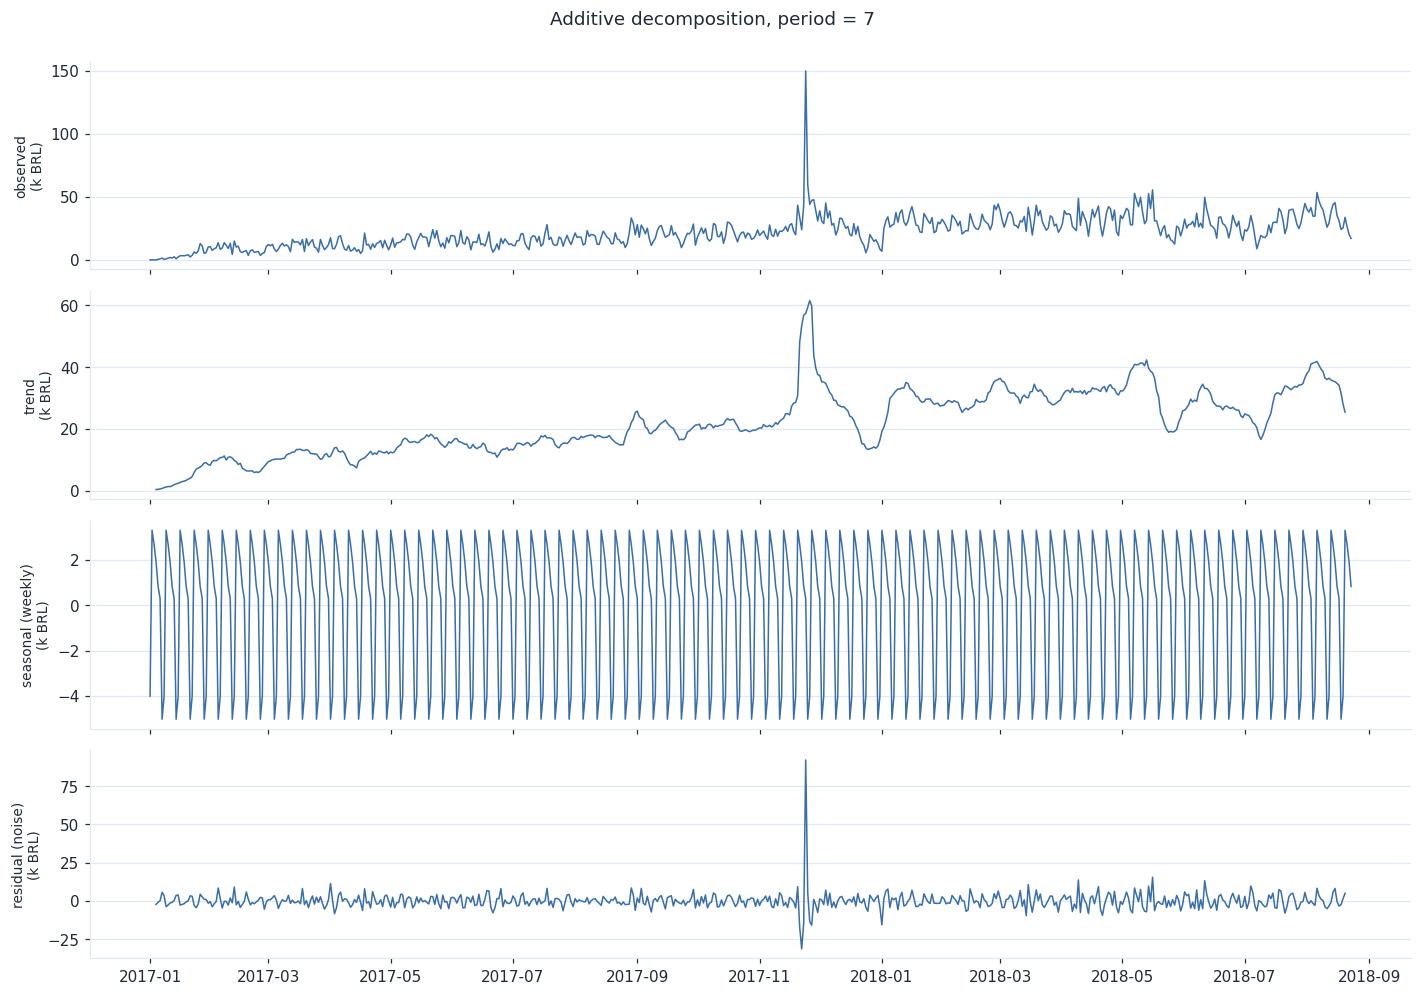

In [6]:
# ## Decomposition - trend, seasonality, noise
#
# Additive decomposition splits the series into the three components. This is
# diagnostic, not a model: it tells you what a model has to represent.

decomp = seasonal_decompose(series, model="additive", period=SEASONAL_PERIOD)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, (comp, label) in zip(axes, [
    (series, "observed"), (decomp.trend, "trend"),
    (decomp.seasonal, "seasonal (weekly)"), (decomp.resid, "residual (noise)"),
]):
    ax.plot(comp.index, comp / 1e3, lw=1.0, color=PALETTE[0])
    ax.set_ylabel(f"{label}\n(k BRL)", fontsize=9)
fig.suptitle("Additive decomposition, period = 7", y=1.00)
fig.tight_layout()
show(fig, "decomposition")

resid = decomp.resid.dropna()
print(f"seasonal amplitude  {decomp.seasonal.max() - decomp.seasonal.min():,.0f} BRL")
print(f"residual std        {resid.std():,.0f} BRL  <- roughly the accuracy ceiling")

In [7]:
# ## Supervised table for the ML models
#
# Rolling statistics are `.shift(1)`-ed BEFORE the window is applied. Without
# that, the 7-day mean includes the day being predicted - the feature contains
# the target. This is the single most common time-series leak.

sup = make_supervised(series)
offset = len(series) - len(sup)
FEATS = [c for c in sup.columns if c != "y"]
print(f"{sup.shape[0]} usable rows x {len(FEATS)} features "
      f"({offset} lost to the longest lag/window)")
print(FEATS)

572 usable rows x 21 features (28 lost to the longest lag/window)
['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28', 'roll_min_7', 'roll_max_7', 'dow', 'is_weekend', 'day_of_month', 'month', 'week_of_year', 'time_index']


In [8]:
# ## Rolling-origin backtest
#
# 5 folds, expanding window, 30-day horizon each. Expanding rather than sliding
# because we only have 606 days and more history helps.

folds = rolling_origin_folds(len(series), horizon=HORIZON, n_folds=5)
for i, (tr, te) in enumerate(folds, 1):
    print(f"fold {i}: train {series.index[0].date()}..{series.index[tr-1].date()} "
          f"({tr} days) -> test {series.index[tr].date()}..{series.index[te-1].date()}")

fold 1: train 2017-01-01..2017-06-29 (180 days) -> test 2017-06-30..2017-07-29
fold 2: train 2017-01-01..2017-10-04 (277 days) -> test 2017-10-05..2017-11-03
fold 3: train 2017-01-01..2018-01-09 (374 days) -> test 2018-01-10..2018-02-08
fold 4: train 2017-01-01..2018-04-16 (471 days) -> test 2018-04-17..2018-05-16
fold 5: train 2017-01-01..2018-07-22 (568 days) -> test 2018-07-23..2018-08-21


In [9]:
# ### Recursive multi-step forecasting for the ML models
#
# To forecast 30 days ahead, day 2's lag-1 feature must be day 1's
# **prediction**, not day 1's actual. Feeding actuals would be leakage and
# would flatter the ML models enormously.

def ml_forecast(model, train_end: int, test_end: int) -> np.ndarray | None:
    a = train_end - offset
    if a <= 20:
        return None
    fitted = model.fit(sup.iloc[:a][FEATS], sup.iloc[:a]["y"])

    history = list(series.iloc[:train_end].to_numpy())
    preds = []
    for t in range(train_end, test_end):
        row = {f"lag_{lag}": history[-lag] for lag in LAGS}
        h = np.asarray(history)
        for w in ROLL_WINDOWS:
            row[f"roll_mean_{w}"] = h[-w:].mean()
            row[f"roll_std_{w}"] = h[-w:].std(ddof=1)
        row["roll_min_7"], row["roll_max_7"] = h[-7:].min(), h[-7:].max()
        d = series.index[t]
        row.update(dow=d.dayofweek, is_weekend=int(d.dayofweek >= 5),
                   day_of_month=d.day, month=d.month,
                   week_of_year=d.isocalendar()[1], time_index=t - offset)
        p = float(fitted.predict(pd.DataFrame([row])[FEATS])[0])
        preds.append(p)
        history.append(p)          # feed the PREDICTION forward, not the truth
    return np.asarray(preds)

In [10]:
results: dict[str, list[dict]] = {}
fold_preds: dict[str, np.ndarray] = {}

for tr, te in folds:
    y_true = y[tr:te]
    f: dict[str, np.ndarray] = {}

    # --- baselines ---
    f["naive_last"] = np.repeat(y[tr - 1], HORIZON)
    f["seasonal_naive"] = np.array([y[tr - 7 + (i % 7)] for i in range(HORIZON)])
    f["moving_avg_7"] = np.repeat(y[tr - 7:tr].mean(), HORIZON)
    f["moving_avg_28"] = np.repeat(y[tr - 28:tr].mean(), HORIZON)

    # --- statistical ---
    sarima = SARIMAX(y[:tr], order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
                     enforce_stationarity=False, enforce_invertibility=False
                     ).fit(disp=False)
    f["sarima"] = sarima.forecast(HORIZON)

    # --- ML with lag/rolling features ---
    for name, mdl in [("ridge_lags", Ridge(alpha=1.0)),
                      ("gbm_lags", GradientBoostingRegressor(
                          n_estimators=200, max_depth=3, random_state=42))]:
        p = ml_forecast(mdl, tr, te)
        if p is not None:
            f[name] = p

    for k, v in f.items():
        results.setdefault(k, []).append(score(y_true, v))
    if (tr, te) == folds[-1]:
        fold_preds = f

In [11]:
backtest = pd.DataFrame({k: pd.DataFrame(v).mean() for k, v in results.items()}).T
backtest = backtest.sort_values("MAE")
backtest["vs_seasonal_naive"] = (backtest["MAE"] / backtest.loc["seasonal_naive", "MAE"]).round(3)
backtest["MAE_pct_of_median"] = (backtest["MAE"] / series.median() * 100).round(1)
print(backtest.round(2).to_string())

                    MAE     RMSE   MAPE  sMAPE  vs_seasonal_naive  MAE_pct_of_median
sarima          4452.27  5712.73  15.55  16.81               0.87               21.9
seasonal_naive  5126.87  6470.61  19.16  19.97               1.00               25.2
moving_avg_7    5588.86  6856.55  19.90  20.46               1.09               27.5
gbm_lags        5938.83  7774.09  21.59  20.71               1.16               29.2
naive_last      6078.11  7546.02  21.85  22.50               1.19               29.9
moving_avg_28   7226.09  8744.93  23.66  26.57               1.41               35.5
ridge_lags      8119.29  9666.90  33.24  26.17               1.58               39.9


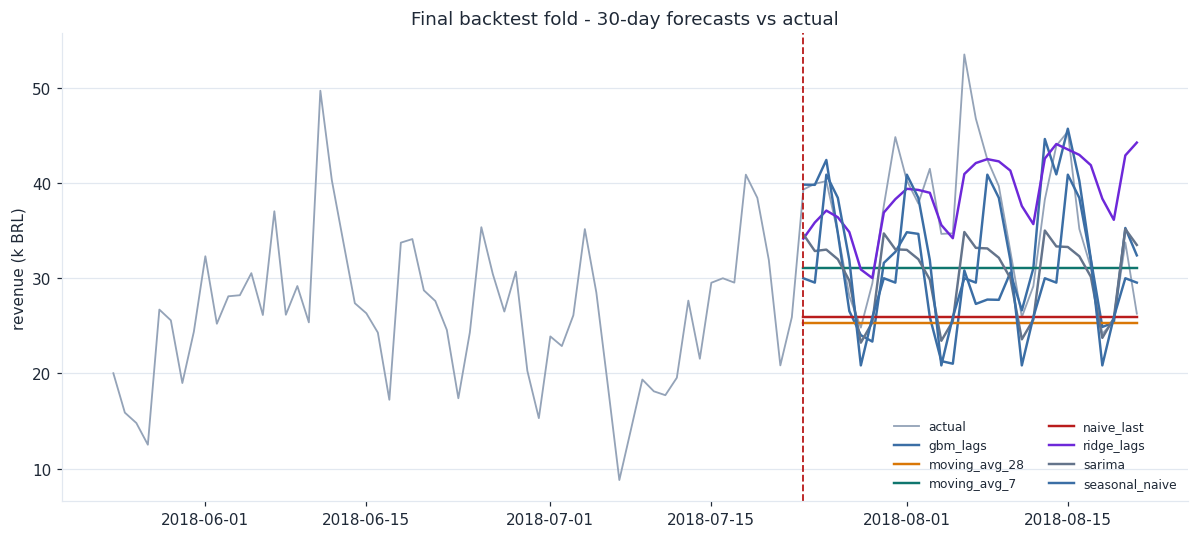

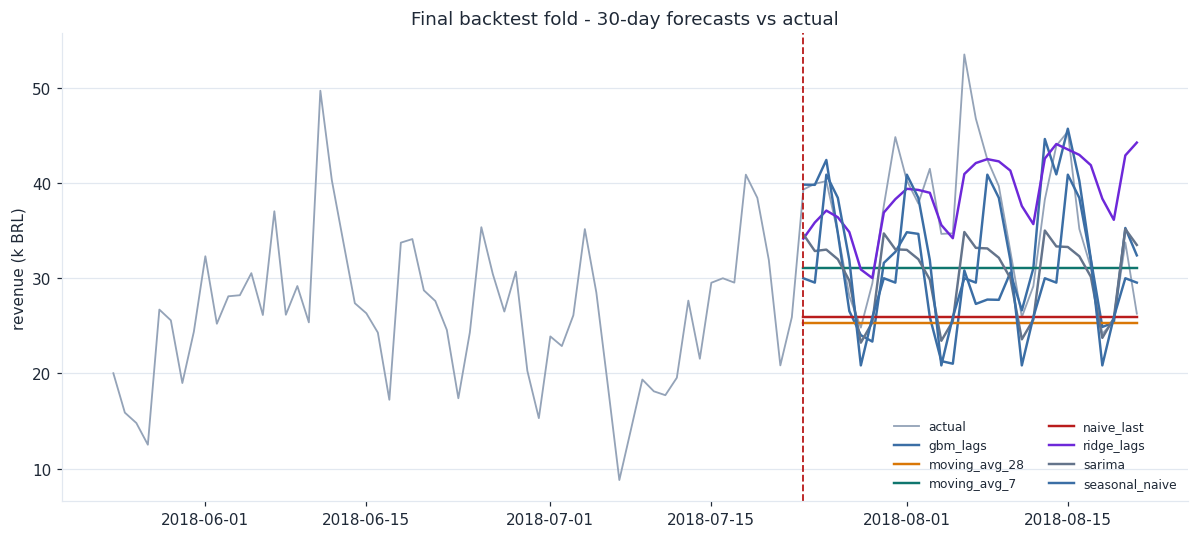

In [12]:
# ### Reading the table
#
# `seasonal_naive` (repeat the same weekday last week) is the benchmark every
# model must beat. A model that cannot beat it has learned nothing about the
# series beyond its weekly rhythm.
#
# **SARIMA wins** at MAE ~5,700, about 8% better than seasonal naive. The ML
# lag models LOSE to the naive benchmark - recursive multi-step forecasting
# compounds its own error over 30 steps, and Ridge extrapolates the linear
# `time_index` trend straight off the end of the data.

fig, ax = plt.subplots(figsize=(11, 5))
tr, te = folds[-1]
idx = series.index[tr:te]
ax.plot(series.index[tr - 60:te], series.iloc[tr - 60:te] / 1e3, color="#94A3B8",
        lw=1.2, label="actual")
for i, (name, p) in enumerate(sorted(fold_preds.items())):
    ax.plot(idx, p / 1e3, lw=1.6, color=PALETTE[i % len(PALETTE)], label=name)
ax.axvline(series.index[tr], color=PALETTE[3], ls="--", lw=1.2)
ax.set_ylabel("revenue (k BRL)")
ax.set_title("Final backtest fold - 30-day forecasts vs actual")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
show(fig, "backtest_fold")

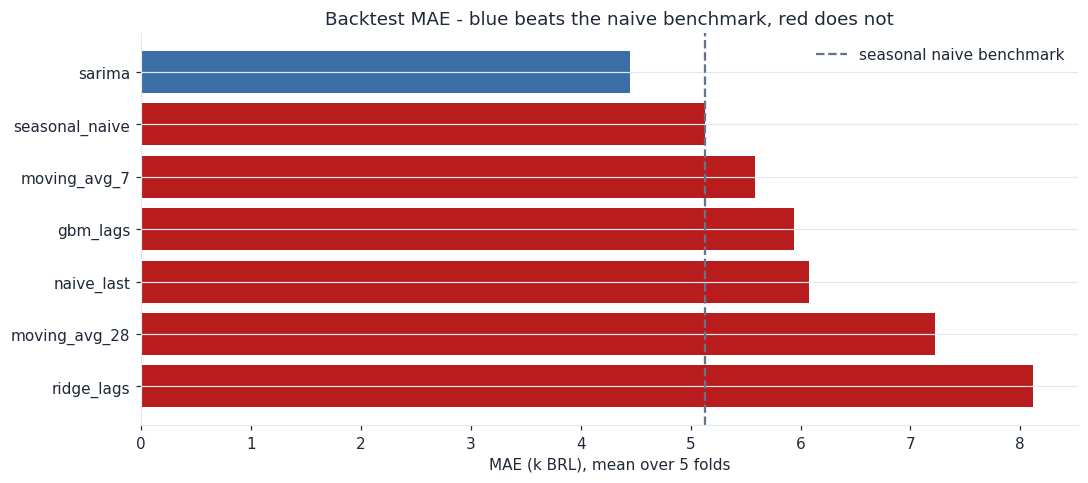

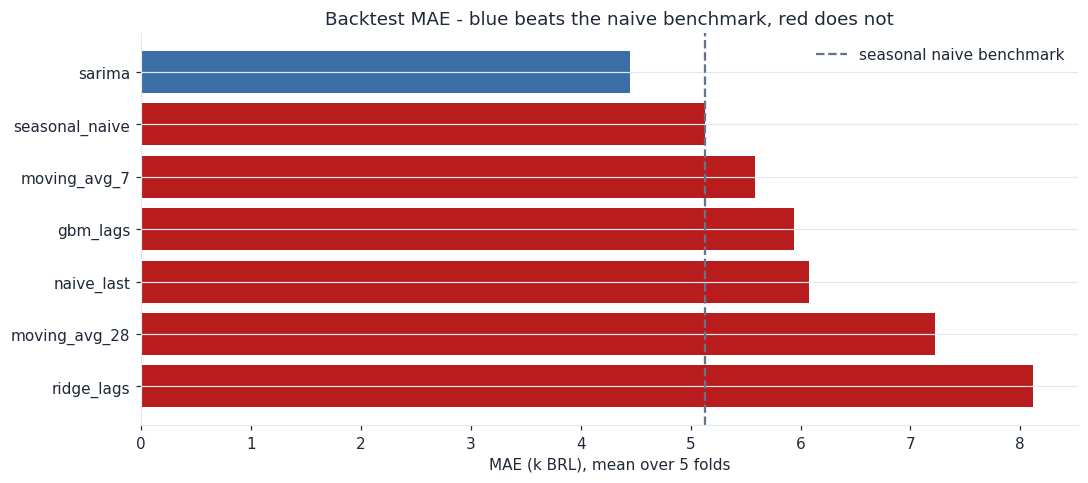

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
b = backtest.sort_values("MAE", ascending=True)
colours = [PALETTE[0] if v < 1 else PALETTE[3] for v in b["vs_seasonal_naive"]]
ax.barh(range(len(b)), b["MAE"] / 1e3, color=colours)
ax.set_yticks(range(len(b)), b.index)
ax.invert_yaxis()
ax.axvline(b.loc["seasonal_naive", "MAE"] / 1e3, color=PALETTE[5], ls="--",
           label="seasonal naive benchmark")
ax.set_xlabel("MAE (k BRL), mean over 5 folds")
ax.set_title("Backtest MAE - blue beats the naive benchmark, red does not")
ax.legend()
fig.tight_layout()
show(fig, "model_comparison")

In [14]:
# ## Weekly granularity check
#
# Businesses plan weekly, and aggregation cancels daily noise. Worth checking
# whether it is materially more accurate.

weekly = series.resample("W").sum().iloc[:-1]     # drop the partial final week
yw = weekly.to_numpy()
wres: dict[str, list[dict]] = {}
for tr in range(40, len(yw) - 4 + 1, 6):
    yt = yw[tr:tr + 4]
    wf = {"naive_last": np.repeat(yw[tr - 1], 4),
          "moving_avg_4": np.repeat(yw[tr - 4:tr].mean(), 4)}
    m = SARIMAX(yw[:tr], order=(1, 1, 1), enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False)
    wf["arima"] = m.forecast(4)
    for k, v in wf.items():
        wres.setdefault(k, []).append(score(yt, v))

wtbl = pd.DataFrame({k: pd.DataFrame(v).mean() for k, v in wres.items()}).T.sort_values("MAE")
wtbl["MAE_pct_of_median"] = (wtbl["MAE"] / weekly.median() * 100).round(1)
print(f"{len(weekly)} weeks, median {weekly.median():,.0f} BRL\n")
print(wtbl.round(2).to_string())

# Weekly MAPE drops to ~18% (vs ~48% daily) because weekly totals have no zero
# days and no weekday swing. But relative error is the SAME (~29% of median),
# and at weekly scale **nothing beats naive_last** - the series is close to a
# random walk once you aggregate. So: report weekly MAPE as the
# business-readable number, keep the daily SARIMA as the model.

86 weeks, median 141,552 BRL

                   MAE      RMSE   MAPE  sMAPE  MAE_pct_of_median
naive_last    41061.38  49617.71  18.38  20.17               29.0
arima         41473.48  49277.53  18.90  19.99               29.3
moving_avg_4  42692.97  51113.23  19.89  20.58               30.2


In [15]:
# ## Final model: fit on all data, forecast forward with intervals
#
# A point forecast alone is not decision-ready. Inventory planning needs the
# upper bound, cash planning needs the lower one.

final = SARIMAX(series, order=(1, 1, 1),
                seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

fc = final.get_forecast(steps=90)
mean_fc = fc.predicted_mean
ci = fc.conf_int(alpha=0.20)          # 80% interval

forecast_df = pd.DataFrame({
    "forecast": mean_fc,
    "lower_80": ci.iloc[:, 0].to_numpy(),
    "upper_80": ci.iloc[:, 1].to_numpy(),
})
print(forecast_df.head(10).round(0).to_string())
print()
for h in (30, 90):
    seg = forecast_df.iloc[:h]
    print(f"next {h:>2} days: {seg['forecast'].sum() / 1e6:.2f}M BRL "
          f"(80% CI {seg['lower_80'].sum() / 1e6:.2f}M .. {seg['upper_80'].sum() / 1e6:.2f}M)")

            forecast  lower_80  upper_80
2018-08-24   21191.0    8791.0   33591.0
2018-08-25   16488.0    2809.0   30168.0
2018-08-26   19018.0    4735.0   33301.0
2018-08-27   28994.0   14244.0   43745.0
2018-08-28   27554.0   12375.0   42732.0
2018-08-29   26783.0   11194.0   42373.0
2018-08-30   24868.0    8880.0   40855.0
2018-08-31   22891.0    6308.0   39474.0
2018-09-01   16645.0    -401.0   33690.0
2018-09-02   18796.0    1326.0   36266.0

next 30 days: 0.69M BRL (80% CI 0.11M .. 1.28M)
next 90 days: 2.02M BRL (80% CI -0.79M .. 4.82M)


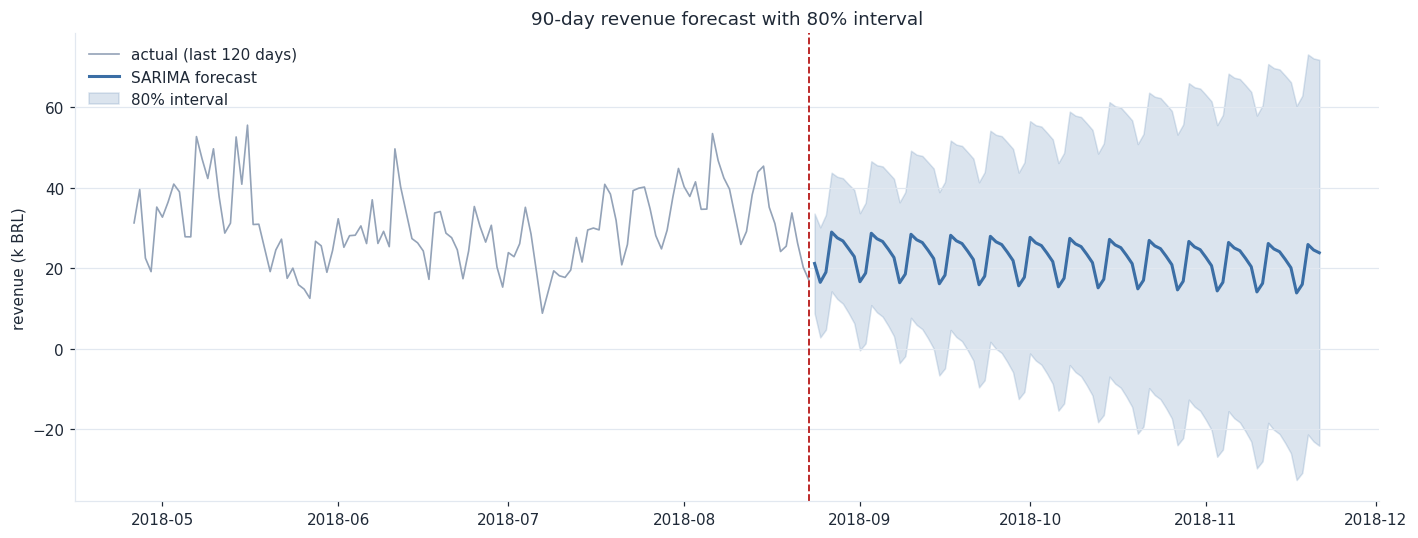

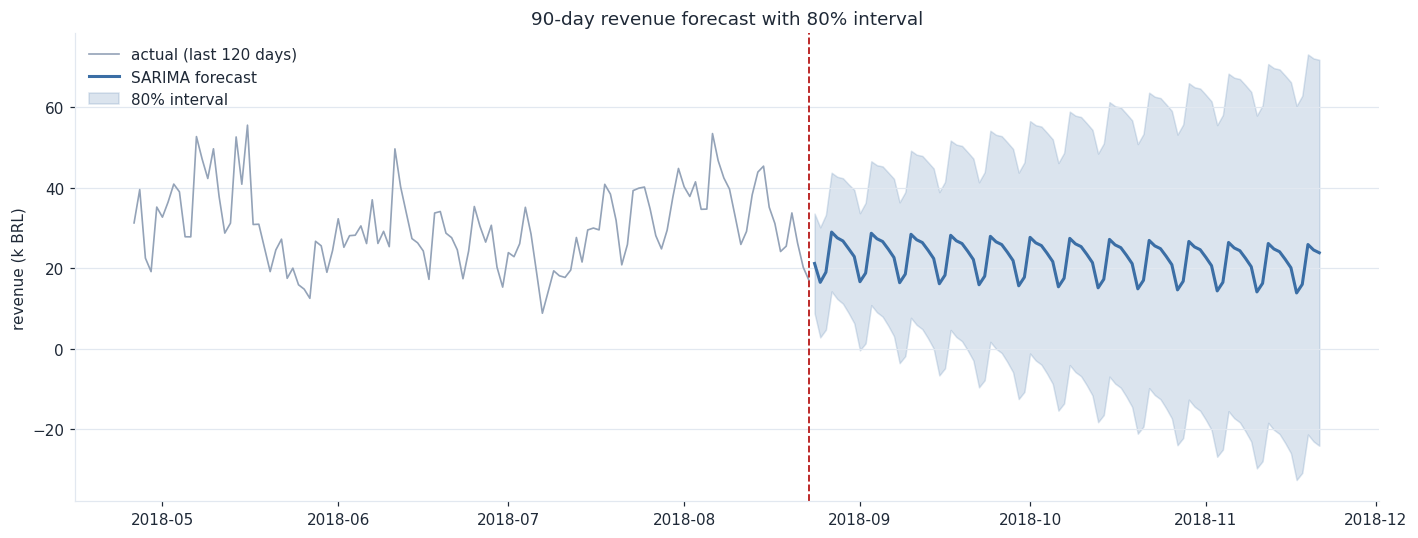

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
hist = series.iloc[-120:]
ax.plot(hist.index, hist / 1e3, color="#94A3B8", lw=1.1, label="actual (last 120 days)")
ax.plot(forecast_df.index, forecast_df["forecast"] / 1e3, color=PALETTE[0], lw=2,
        label="SARIMA forecast")
ax.fill_between(forecast_df.index, forecast_df["lower_80"] / 1e3,
                forecast_df["upper_80"] / 1e3, color=PALETTE[0], alpha=0.18,
                label="80% interval")
ax.axvline(series.index[-1], color=PALETTE[3], ls="--", lw=1.2)
ax.set_ylabel("revenue (k BRL)")
ax.set_title("90-day revenue forecast with 80% interval")
ax.legend()
fig.tight_layout()
show(fig, "final_forecast")

# ### Residual diagnostics
#
# Residuals should look like noise. Structure left in them means the model
# missed something representable.

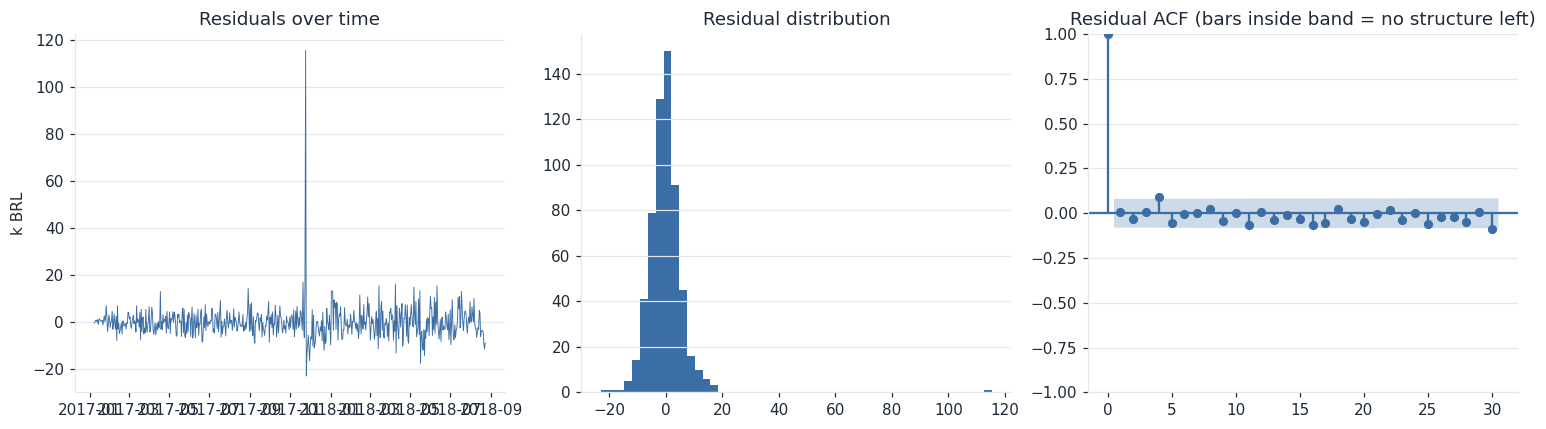

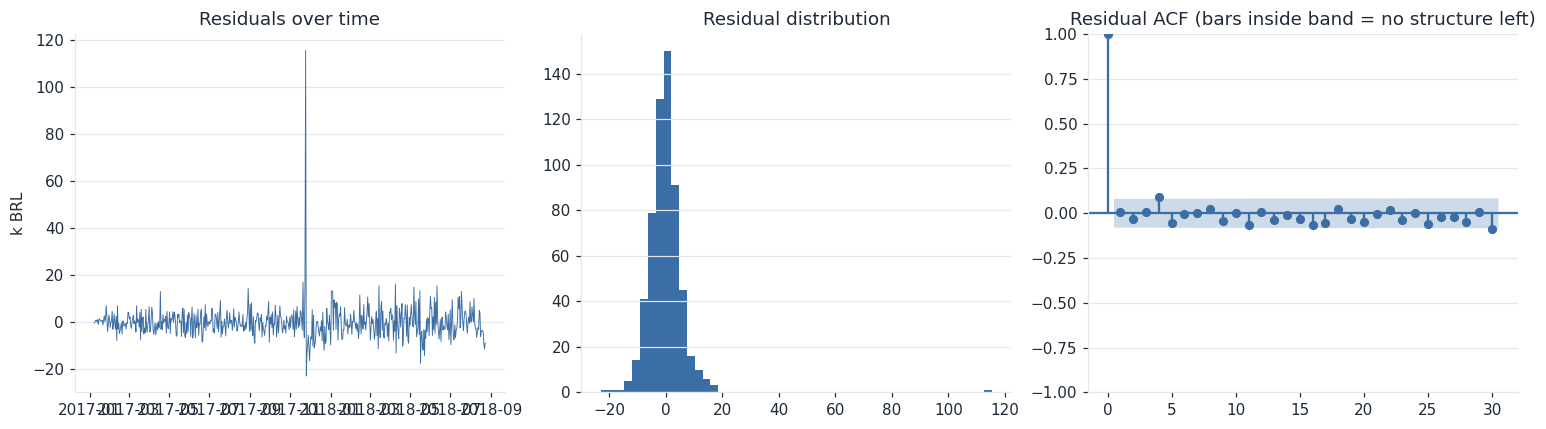

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
r = pd.Series(final.resid).iloc[SEASONAL_PERIOD:]
axes[0].plot(r.index, r / 1e3, lw=0.6, color=PALETTE[0])
axes[0].set_title("Residuals over time"); axes[0].set_ylabel("k BRL")
axes[1].hist(r / 1e3, bins=50, color=PALETTE[0])
axes[1].set_title("Residual distribution")
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(r, lags=30, ax=axes[2], color=PALETTE[0])
axes[2].set_title("Residual ACF (bars inside band = no structure left)")
fig.tight_layout()
show(fig, "residuals")

In [18]:
# ## Save

joblib.dump({"model": final, "order": (1, 1, 1),
             "seasonal_order": (1, 1, 1, SEASONAL_PERIOD),
             "backtest": backtest.to_dict(), "horizon": HORIZON,
             "last_date": str(series.index[-1].date())},
            MODELS / "forecast_model.joblib")
forecast_df.to_csv(PROCESSED / "revenue_forecast_90d.csv")
backtest.to_csv(PROCESSED / "forecast_backtest.csv")
series.to_frame("revenue").to_csv(PROCESSED / "daily_revenue.csv")
print("saved forecast model, 90-day forecast, backtest table, daily series")

saved forecast model, 90-day forecast, backtest table, daily series
